1. divide my data to 5 year non-overlapping window in age (people 20-24, 25-29, 30-34 etc.)

2. Per ROI, and per age window, I want to find the slope of birth year (b1)
the regression model is:

for age_window:

GMV_ROI_1 ~ b1*birth_year

3. after calculating all b1 for all age windows, I want to present them in a plot (y axis is GMV, x axisis birth year).

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from tqdm import tqdm
import re

In [2]:
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
# print(f"networks: {atlas_csv['network'].unique()}")
# print(f"compoments: {atlas_csv['component'].unique()}")

In [3]:
coef_df = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_manual_bins_wuniform.csv')

# take only interesting bins: (20, 25], (25, 30], (30, 35]
coef_df = coef_df[coef_df['age_bin'].isin(['(20, 25]', '(25, 30]', '(30, 35]'])]

unweighted_birth_year_coef_df = coef_df[
    (coef_df['variable'] == 'birth_year') & (coef_df['weighting'] == 'unweighted')
]
weighted_birth_year_coef_df = coef_df[
    (coef_df['variable'] == 'birth_year') & (coef_df['weighting'] == 'weighted')
]
# rename the column 'index' to 'region_label'
atlas_csv = atlas_csv.rename(columns={'index': 'region_label'})

# add the network and component information to the birth_year_coef_df
unweighted_birth_year_coef_df = unweighted_birth_year_coef_df.merge(atlas_csv[['region_label', 'network', 'component', 'hemisphere']], on='region_label', how='left')
weighted_birth_year_coef_df = weighted_birth_year_coef_df.merge(atlas_csv[['region_label', 'network', 'component', 'hemisphere']], on='region_label', how='left')

# Weighted vs. Unweighted 

# Weighted Analysis

In [16]:
birth_year_coef_df = weighted_birth_year_coef_df

stats_list = []
unique_bins = sorted(birth_year_coef_df['age_bin'].unique())

for bin_label in unique_bins:
    # Filter for this bin
    bin_data = birth_year_coef_df[birth_year_coef_df['age_bin'] == bin_label]
    total_rois = bin_data['region_label'].nunique()
    
    # Filter for significant ROIs only
    sig_data = bin_data[bin_data['fdr_p'] < 0.05].copy() # Use .copy() to avoid SettingWithCopyWarning
    num_significant = sig_data.shape[0]
    
    # Calculate percentage
    percentage = (num_significant / total_rois * 100) if total_rois > 0 else 0
    
    # --- Create the combined network+component identifier ---
    # We join them with an underscore for easy reading
    if not sig_data.empty:
        sig_data['net_comp'] = sig_data['network'].astype(str) + "_" + sig_data['component'].astype(str)
        sig_net_comp_list = sig_data['net_comp'].unique().tolist()
        sig_roi_names = sig_data['region_name'].tolist()
        sig_roi_label = sig_data['region_label'].tolist()
    else:
        sig_net_comp_list = []
        sig_roi_names = []
        sig_roi_label = []

    print(f"Age Bin: {bin_label}")
    print(f"  Significant: {num_significant}/{total_rois} ({percentage:.2f}%)")

    # Add results to our list
    stats_list.append({
        'age_bin': bin_label,
        'num_significant': num_significant,
        'total_rois': total_rois,
        'percentage': percentage,
        'list_sig_net_comp': sig_net_comp_list, # The new combined column
        'list_sig_rois': sig_roi_names,
        'list_sig_roi_labels': sig_roi_label
    })

# Create the detailed DataFrame
bin_stats_detailed = pd.DataFrame(stats_list)

Age Bin: (20, 25]
  Significant: 270/454 (59.47%)
Age Bin: (25, 30]
  Significant: 242/454 (53.30%)
Age Bin: (30, 35]
  Significant: 215/454 (47.36%)


In [17]:
# --- Find repeating Network+Component combinations ---
# explode() expands the lists into individual rows
all_sig_net_comp = bin_stats_detailed['list_sig_net_comp'].explode()
net_comp_counts = all_sig_net_comp.value_counts()


print("\nNetwork + Component combinations that appear in multiple age bins:")
for combo, count in net_comp_counts.items():
    if count > 1:
        print(f"  {combo}: appears in {count} age bins")

# find the rois that appear in multiple age bins
all_sig_rois = bin_stats_detailed['list_sig_rois'].explode()
roi_counts = all_sig_rois.value_counts()

print("\nROIs that appear in multiple age bins:")
for roi, count in roi_counts.items():
    if count > 1:
        print(f"  {roi}: appears in {count} age bins")

# add the roi count to birth_year_coef_fd
birth_year_coef_df['roi_count'] = birth_year_coef_df['region_name'].map(roi_counts)


Network + Component combinations that appear in multiple age bins:
  visual_visual: appears in 3 age bins
  somatomotor_somatomotor: appears in 3 age bins
  dorsal attention_posterior: appears in 3 age bins
  dorsal attention_frontal eye fields: appears in 3 age bins
  dorsal attention_precentral ventral: appears in 3 age bins
  salience / ventral attention_parietal operculum: appears in 3 age bins
  salience / ventral attention_frontal operculum insula: appears in 3 age bins
  salience / ventral attention_medial: appears in 3 age bins
  limbic_orbital frontal cortex: appears in 3 age bins
  limbic_temporal pole: appears in 3 age bins
  control_lateral prefrontal cortex: appears in 3 age bins
  control_ventral prefrontal cortex: appears in 3 age bins
  control_cingulate: appears in 3 age bins
  default_temporal: appears in 3 age bins
  default_parietal: appears in 3 age bins
  default_prefrontal cortex: appears in 3 age bins
  default_precuneus posterior cingulate cortex: appears in 3

In [18]:
def string_to_interval(interval_str):
    if pd.isna(interval_str) or not isinstance(interval_str, str):
        return None
    # Remove brackets/parentheses and split by the dash
    # Note: This assumes your ages are always positive!
    clean_str = interval_str.strip("()[] ")
    # split by - or , 
    if "-" in clean_str:
        left, right = clean_str.split("-", 1)
    else:
        left, right = clean_str.split(",", 1)
    return pd.Interval(float(left), float(right), closed='right')

# 1. Convert strings to Interval objects
birth_year_coef_df['age_bin_interval'] = birth_year_coef_df['age_bin'].apply(string_to_interval)

birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['age_bin_interval'].apply(lambda x: x.mid)

# Visualization

Trends per ROI 
for all ROIs, no significance filter
Including the significance of the linear model

In [19]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import statsmodels.formula.api as smf

# # # Your specific ROIs
# # roi_list = [421, 422, 448, 449]

# # list rois that the roi_count == 3
# roi_list = birth_year_coef_df[birth_year_coef_df['roi_count'] == 3]['region_label'].unique().tolist()


# for region_of_interest in roi_list:
#     # Filter data for the specific ROI
#     region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest].copy()
    
#     if region_data.shape[0] < 2:
#         print(f"Not enough data points for region {region_of_interest} to plot.")
#         continue

#     # 1. Add significance flag for coloring
#     region_data['is_significant'] = region_data['fdr_p'] < 0.05
    
#     # 2. Fit Linear Regression
#     model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    
#     # 3. Plotting
#     plt.figure(figsize=(7, 4))
    
#     # Draw the gray connecting line first
#     sns.lineplot(
#         data=region_data,
#         x='mid_age_bin',
#         y='coef',
#         color='lightgray',
#         zorder=1,
#         legend=False
#     )
    
#     # Draw colored markers on top
#     # Significant = Teal/Blue, Non-significant = Gray
#     sns.scatterplot(
#         data=region_data,
#         x='mid_age_bin',
#         y='coef',
#         hue='is_significant',
#         palette={True: 'steelblue', False: 'lightgray'},
#         style='is_significant',
#         markers={True: 'o', False: 'X'},
#         s=60,
#         zorder=2
#     )

#     # Add the regression line
#     sns.regplot(
#         data=region_data,
#         x='mid_age_bin',
#         y='coef',
#         scatter=False,
#         ci=None,
#         line_kws={'color': 'red', 'label': f'Trend (p={model.pvalues.iloc[1]:.3f})', 'alpha': 0.6},
#         label='Linear Fit'
#     )

#     # Aesthetics
#     plt.axhline(0, color='black', lw=0.8, ls='--') # Baseline
#     plt.title(f'Birth Year Coefficient Trend: Region {region_of_interest}', fontsize=12)
#     plt.xlabel('Mid-Age of Window (Years)')
#     plt.ylabel('Birth Year Coefficient (β)')
    
#     # Fix legend
#     handles, labels = plt.gca().get_legend_handles_labels()
#     plt.legend(handles, ['Non-Significant', 'FDR < 0.05', 'Linear Trend'], loc='best', fontsize='small')
    
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

In [20]:
# # add to atlas_csv the roi_count column
# atlas_csv['roi_count'] = atlas_csv['name'].map(roi_counts)
# atlas_csv['network_component'] = atlas_csv['network'] + '_' + atlas_csv['component']

# # 1. Find components where ALL ROIs have roi_count == 3
# # We group by 'component' and check if the condition (roi_count == 3) is true for every row in that group
# fully_qualified_components = atlas_csv.groupby('network_component')['roi_count'].transform(lambda x: (x == 3).all())
# component_names = atlas_csv[fully_qualified_components]['network_component'].unique()

# if len(component_names) > 0:
#     print("Components where ALL ROIs have roi_count == 3:")
#     for name in sorted(component_names):
#         print(f"  {name}")
# else:
#     print("No component has all ROIs with roi_count == 3")

# # 2. Find networks where ALL ROIs have roi_count == 3
# fully_qualified_networks = atlas_csv.groupby('network')['roi_count'].transform(lambda x: (x == 3).all())
# network_names = atlas_csv[fully_qualified_networks]['network'].unique()

# if len(network_names) > 0:
#     print("\nNetwork names where ALL ROIs have roi_count == 3:")
#     for name in sorted(network_names):
#         print(f"  {name}")
# else:
#     print("No network has all ROIs with roi_count == 3")

# plot specific for amygdala

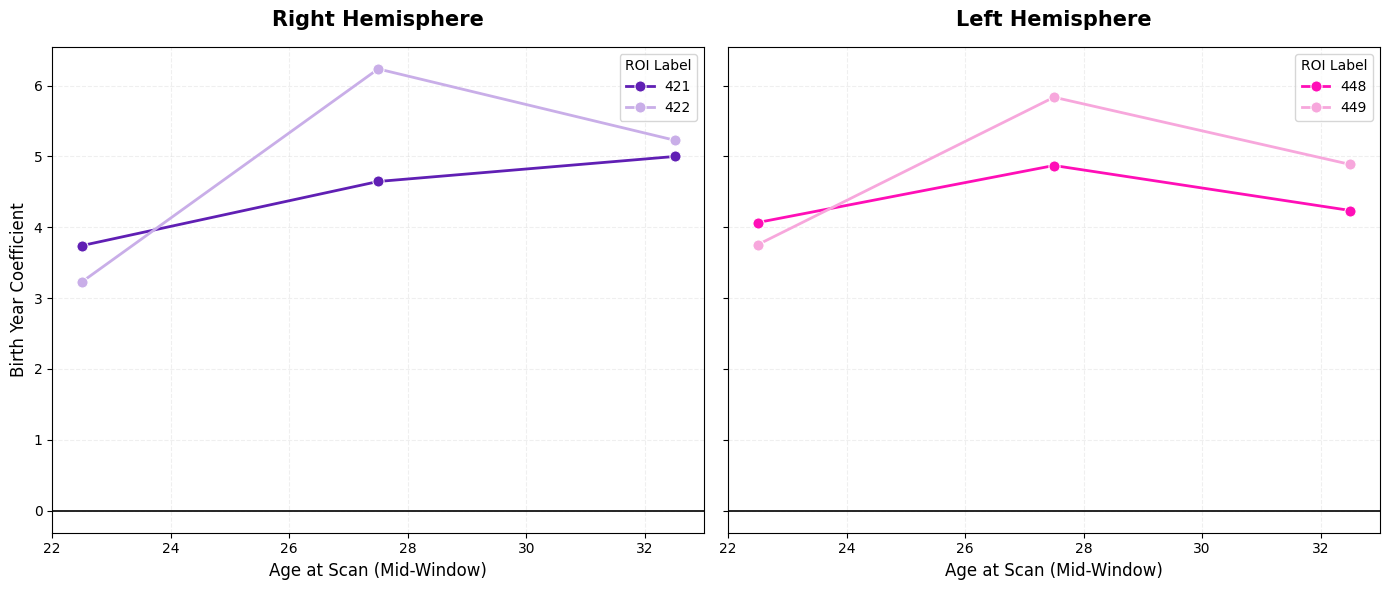

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the hemisphere groupings
hemispheres = {
    'Right Hemisphere': [421, 422],
    'Left Hemisphere': [448, 449]
}

# 1. Setup the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Define a consistent color palette for the 4 specific ROIs
roi_colors = {421: "#601fb4", 422: "#c9aee8", 448: "#ff0eb7", 449: "#f7a7dc"}

for i, (hemi_name, rois) in enumerate(hemispheres.items()):
    ax = axes[i]
    
    # Filter data for the specific ROIs in this hemisphere
    hemi_data = birth_year_coef_df[birth_year_coef_df['region_label'].isin(rois)].copy()
    
    if hemi_data.empty:
        ax.set_title(f"{hemi_name} (No Data)")
        continue

    # 2. Plot lines for each ROI individually
    sns.lineplot(
        data=hemi_data,
        x='mid_age_bin',
        y='coef',
        hue='region_label',
        palette=roi_colors,
        marker='o',
        markersize=8,
        linewidth=2,
        ax=ax
    )

    # 3. Aesthetics
    ax.axhline(0, color='black', lw=1.2, ls='-') # Baseline 0
    ax.set_title(hemi_name, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Age at Scan (Mid-Window)', fontsize=12)
    
    if i == 0:
        ax.set_ylabel('Birth Year Coefficient', fontsize=12)
    else:
        ax.set_ylabel("")

    ax.grid(True, alpha=0.2, linestyle='--')
    
    # 4. Legend Handling
    ax.legend(title="ROI Label", loc='best', frameon=True)

# Adjust layout to prevent label clipping
plt.tight_layout()
plt.show()

# visualize significant ROIs

In [22]:
significant_birth_year_coef_df = birth_year_coef_df[birth_year_coef_df['fdr_p'] < 0.05]


# ROI trend per network

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Iterate through each network
# for network, df_group in significant_birth_year_coef_df.groupby('network'):
#     # Check if this network contains the relevant variable
#     if not any(df_group['variable'] == 'birth_year'):
#         continue

#     # Filter data specifically for this network's regions
#     roi_labels = df_group['region_label'].unique()
#     df_plot = significant_birth_year_coef_df[significant_birth_year_coef_df['region_label'].isin(roi_labels)].copy()

#     plt.figure(figsize=(12, 7))
    
#     # 1. Plot a line for EVERY region in this network
#     # Using 'region_label' as hue gives each region its own color
#     sns.lineplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         hue='region_label', 
#         marker='o',
#         alpha=0.7, 
#         palette='winter', 
#         legend=True
#     )

#     # 2. ADDED: Plot the MEAN trend averaged over all regions
#     # By omitting 'hue', Seaborn aggregates all regions at each age bin
#     sns.lineplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         color='hotpink',
#         linewidth=3,
#         marker='X',
#         label='Network Average',
#         errorbar=('ci', 95) # Adds a shadow showing the 95% CI of the mean
#     )

#     # 2. Add the overall linear trend for the entire network
#     sns.regplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         scatter=False,
#         ci=None,
#         line_kws={'color': 'black', 'linestyle': '--', 'label': 'Network Trend'}
#     )

#     # 3. add a red line at 0
#     plt.axhline(0, color='red', linestyle=':', label='Zero Coefficient')

#     # plt.title(f'Averaged Birth Year Coefficient for {network} Network', fontsize = 20)
#     plt.title(f'{network} Network', fontsize = 20)

#     plt.xlabel('Age Bin', fontsize=16)
#     plt.ylabel('Birth Year Coefficient', fontsize=16)
#     plt.xticks(rotation=45)
    
#     # Move legend outside the plot since there might be many regions
#     plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
    
#     plt.grid(True, linestyle=':', alpha=0.6)
#     plt.tight_layout()
#     plt.show()

# ROI trend per component

In [24]:
# # Iterate through each component
# for component, df_group in significant_birth_year_coef_df.groupby('component'):
#     # Check if this component contains the relevant variable
#     if not any(df_group['variable'] == 'birth_year'):
#         continue

#     # Filter data specifically for this component's regions
#     roi_labels = df_group['region_label'].unique()
#     df_plot = significant_birth_year_coef_df[significant_birth_year_coef_df['region_label'].isin(roi_labels)].copy()

#     plt.figure(figsize=(12, 7))
    
#     # 1. Plot a line for EVERY region in this component
#     # Using 'region_label' as hue gives each region its own color
#     sns.lineplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         hue='region_label', 
#         marker='o',
#         alpha=0.7, 
#         palette='winter'
#     )

#     # 2. Add the overall linear trend for the entire component
#     sns.regplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         scatter=False,
#         ci=None,
#         line_kws={'color': 'black', 'linestyle': '--', 'label': 'Component Trend'}
#     )

#     # 3. add a red line at 0
#     plt.axhline(0, color='red', linestyle=':', label='Zero Coefficient')

#     plt.title(f'Birth Year Coefficient by Region: {component}')
#     plt.xlabel('Age Bin')
#     plt.ylabel('Birth Year Coefficient')
#     plt.xticks(rotation=45)
    
#     # Move legend outside the plot since there might be many regions
#     plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
    
#     plt.grid(True, linestyle=':', alpha=0.6)
#     plt.tight_layout()
#     plt.show()

Linear regression and on to the brain 
The slope of birth year in each age window 
the effect of birth year in each age window

per bin

Processing age bin: (20, 25]


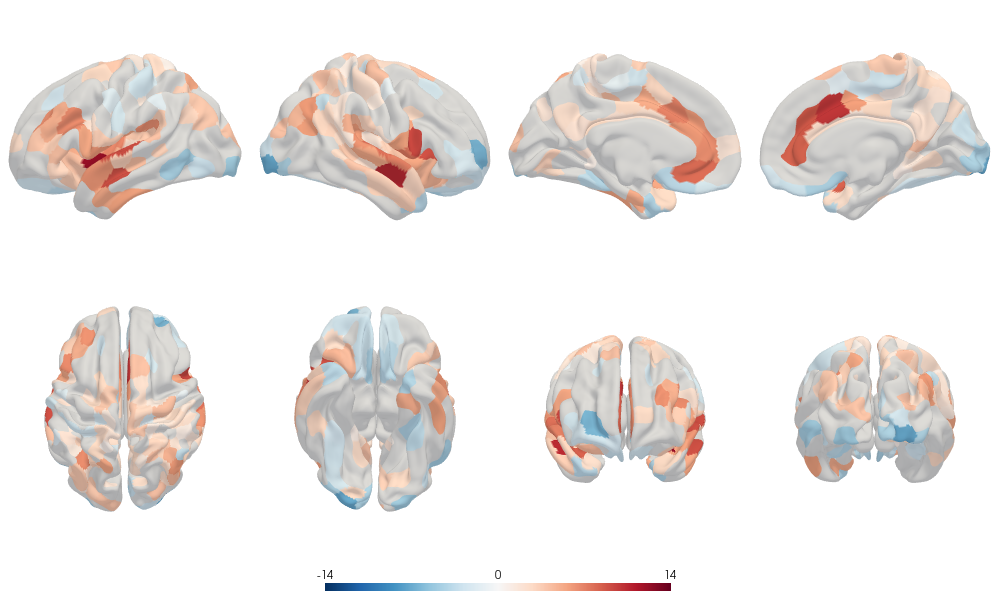

Processing age bin: (25, 30]


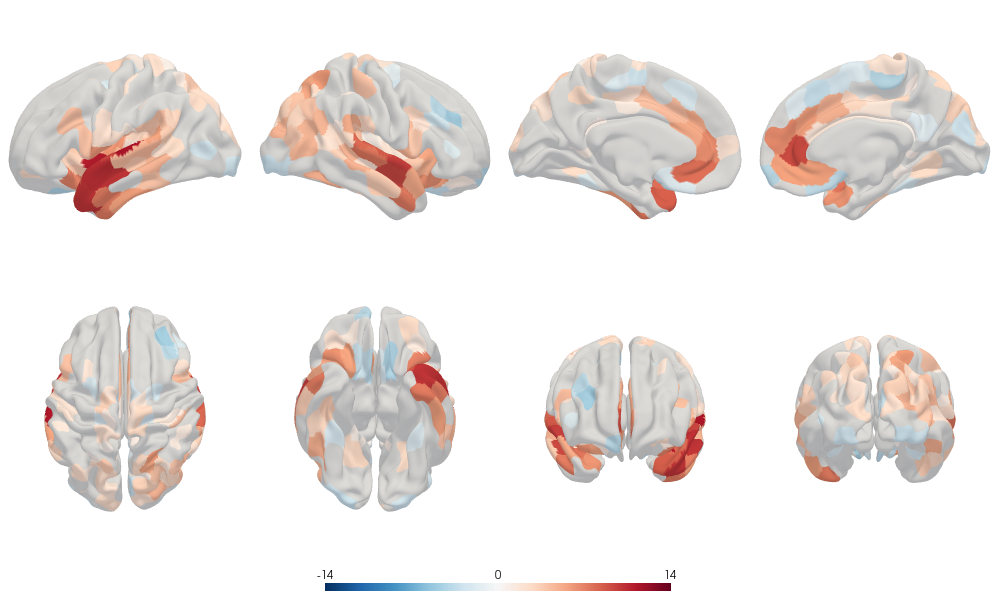

Processing age bin: (30, 35]


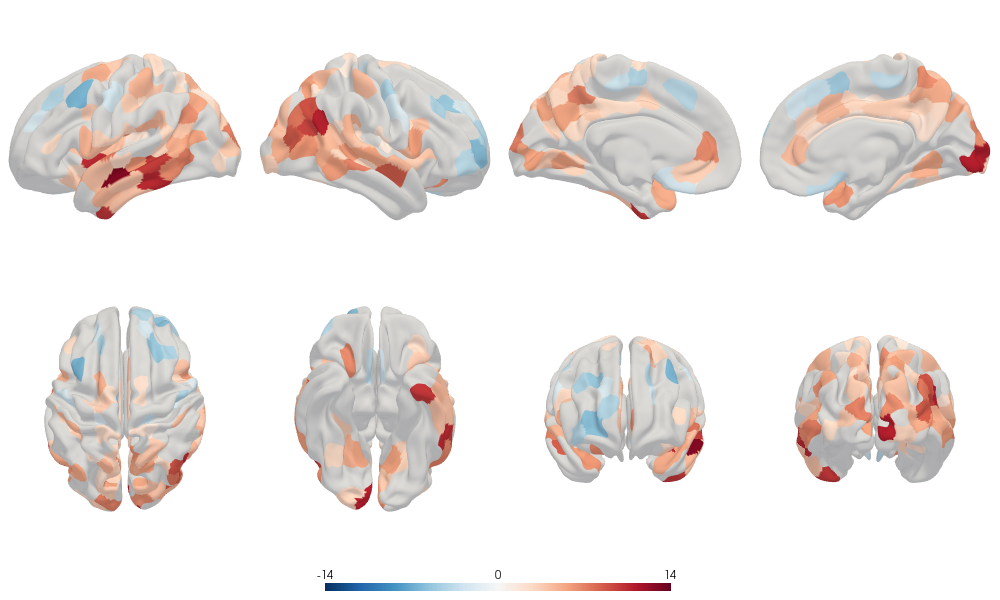

In [ ]:
import numpy as np
import nibabel as nib
from nilearn.image import new_img_like
import yabplot as yp

# --- 1. Load Your Atlas ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()

# --- 2. Loop over age bins ---
for age_bin in birth_year_coef_df['age_bin'].unique():
    print(f"Processing age bin: {age_bin}")
    age_bin_data = birth_year_coef_df[birth_year_coef_df['age_bin'] == age_bin]
    significant_rois_data = age_bin_data[age_bin_data['fdr_p'] < 0.05][['region_name', 'coef']].values.tolist()

    # --- 3. Build data dict: {region_name: coef} for significant ROIs only ---
    # non-significant ROIs will be NaN (white by default)
    all_regions = age_bin_data['region_name'].unique()
    coef_dict = {region: np.nan for region in all_regions}  # default all to NaN
    for region, coef_val in significant_rois_data:
        coef_dict[region] = coef_val

    # --- 4. Plot cortical surface ---
    plotter = yp.plot_cortical(
        data=coef_dict,
        atlas='schaefer400',       
        vminmax=[-14, 14],
        nan_color=(0.85, 0.85, 0.85),  # light gray for non-significant ROIs
        display_type='static',
    )

Processing age bin: (20, 25]


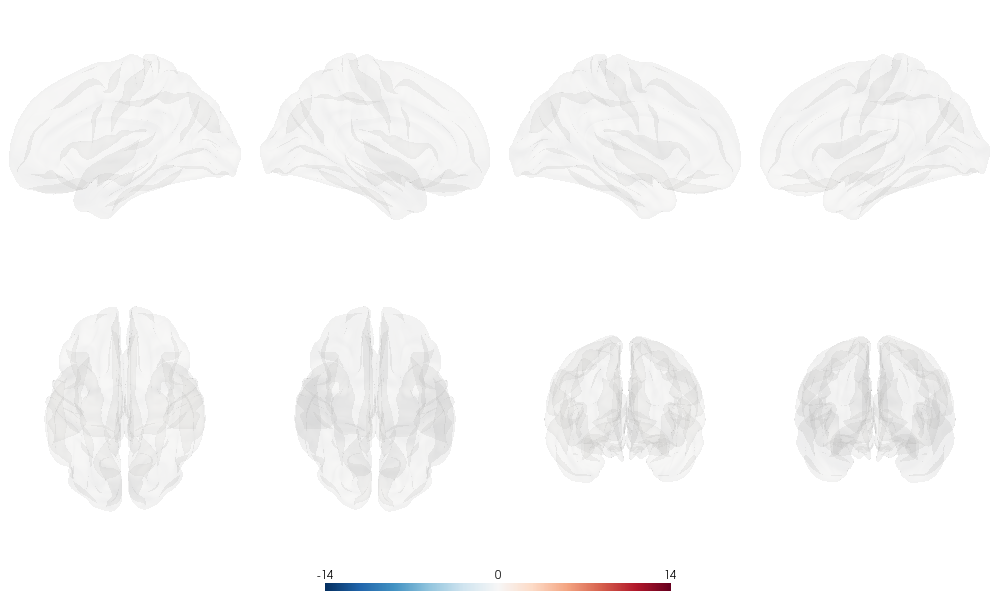

Processing age bin: (25, 30]


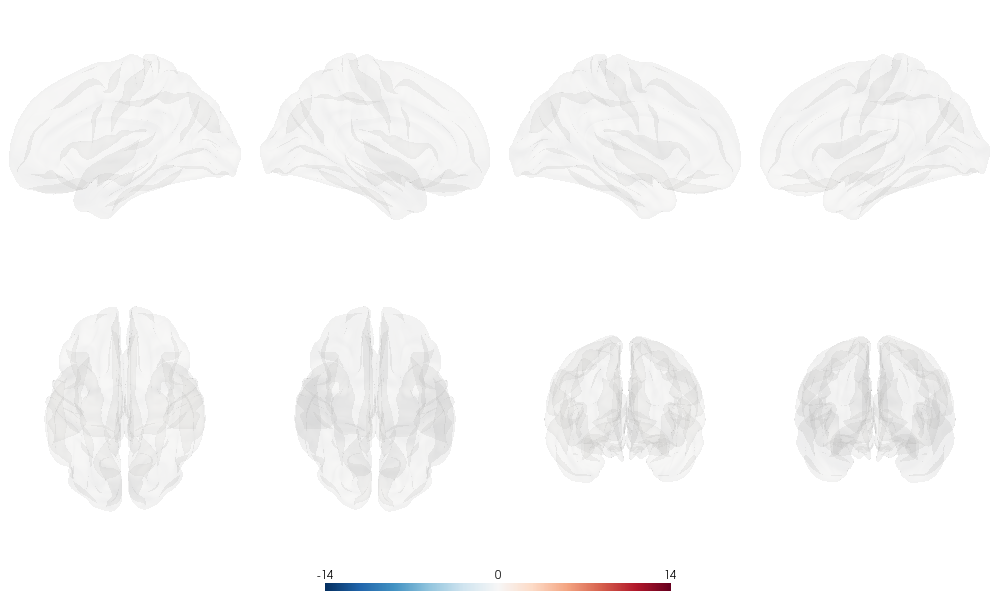

Processing age bin: (30, 35]


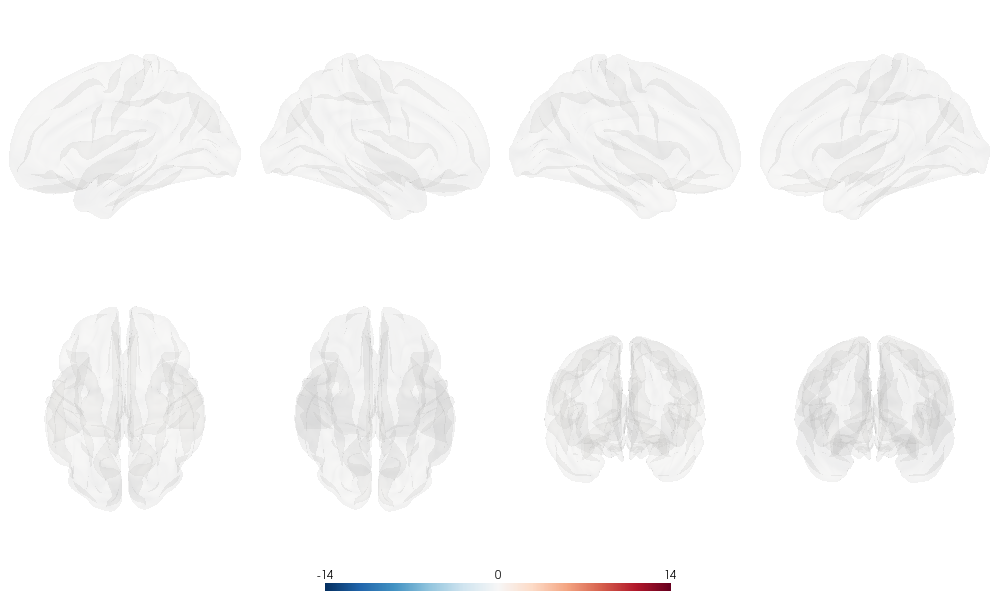

In [ ]:
import numpy as np
import nibabel as nib
from nilearn.image import new_img_like
import yabplot as yp

# --- 1. Load Your Atlas ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()

# --- 2. Loop over age bins ---
for age_bin in birth_year_coef_df['age_bin'].unique():
    print(f"Processing age bin: {age_bin}")
    age_bin_data = birth_year_coef_df[birth_year_coef_df['age_bin'] == age_bin]
    significant_rois_data = age_bin_data[age_bin_data['fdr_p'] < 0.05][['region_name', 'coef']].values.tolist()

    # --- 3. Build data dict: {region_name: coef} for significant ROIs only ---
    # non-significant ROIs will be NaN (white by default)
    all_regions = age_bin_data['region_name'].unique()
    coef_dict = {region: np.nan for region in all_regions}  # default all to NaN
    for region, coef_val in significant_rois_data:
        coef_dict[region] = coef_val

    # --- 4. Plot cortical surface ---
    plotter = yp.plot_cortical(
        data=coef_dict,
        atlas='schaefer400',       
        vminmax=[-14, 14],
        nan_color=(0.85, 0.85, 0.85),  # light gray for non-significant ROIs
        display_type='static',
    )

In [48]:
yp.get_available_resources()

{'cortical': ['aal3',
  'aparc',
  'brainnetome',
  'schaefer100',
  'schaefer1000',
  'schaefer200',
  'schaefer300',
  'schaefer400'],
 'subcortical': ['aal3',
  'aal3_nocer',
  'aseg',
  'brainnetome_sc',
  'musus100',
  'musus100_dbn',
  'musus100_tha',
  'tian2020_s1'],
 'tracts': ['hcp1065_medium',
  'hcp1065_small',
  'hcp1065_tiny',
  'xtract_large',
  'xtract_medium',
  'xtract_small',
  'xtract_tiny'],
 'bmesh': ['inflated',
  'midthickness',
  'pial',
  'swm',
  'very_inflated',
  'white'],
 'label': ['nomedialwall']}

In [49]:
# Check what region names yabplot expects
yp_regions = yp.get_atlas_regions('tian2020_s1')  # or whatever your atlas name is
print("yabplot expects:", yp_regions)

# Check what region names you have in your df
your_regions = birth_year_coef_df['region_name'].unique()
print("Your df has:", your_regions)

yp_regions_set = set(yp_regions)
your_regions_set = set(your_regions)

print("In your df but NOT in yabplot:", your_regions_set - yp_regions_set)
print("In yabplot but NOT in your df:", yp_regions_set - your_regions_set)

TypeError: get_atlas_regions() missing 1 required positional argument: 'category'

Processing age bin: (20, 25]
Mapping 270 significant coef...
Created coef-map image for visualization.


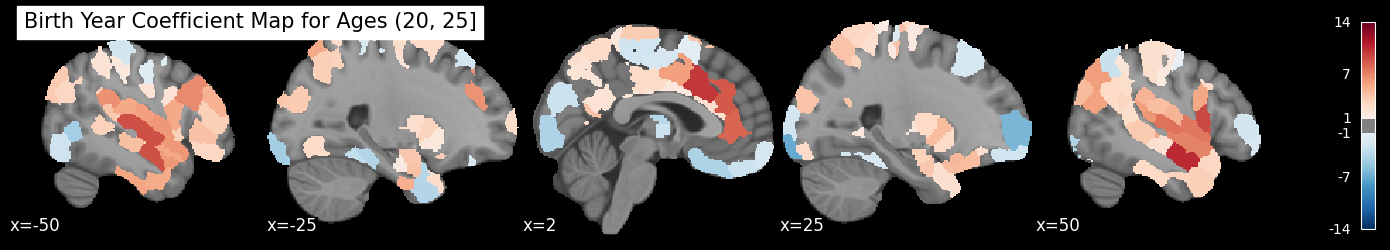

Processing age bin: (25, 30]
Mapping 242 significant coef...
Created coef-map image for visualization.


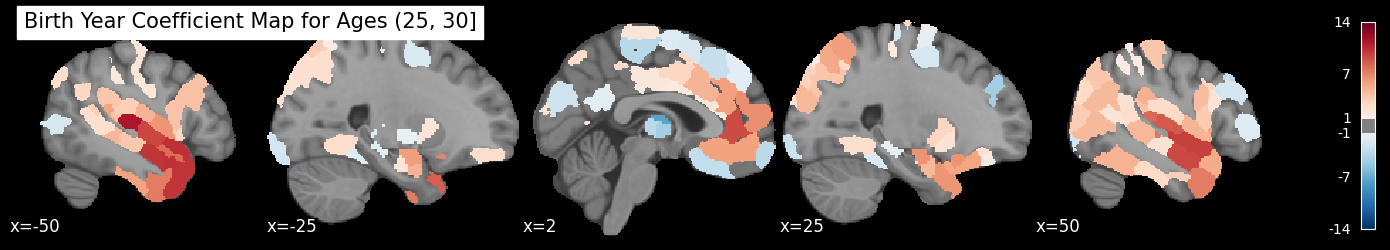

Processing age bin: (30, 35]
Mapping 215 significant coef...
Created coef-map image for visualization.


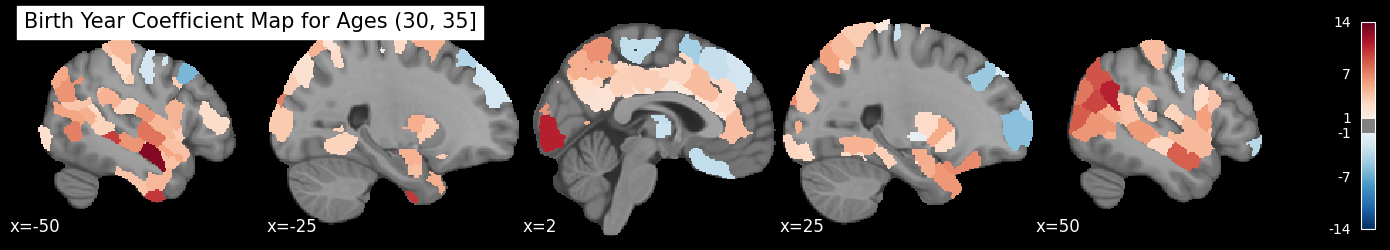

In [29]:
# visualization of significant results on the brain, birth_year

import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.image import new_img_like
from nilearn.datasets import load_mni152_template # for background image

# --- 1. Load Your Atlas ---
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()


# --- 2. Extract significant coefficients from your results_df ---

# for each age_bin, plot the significant ROIs with their coef values
for age_bin in birth_year_coef_df['age_bin'].unique():
    print(f"Processing age bin: {age_bin}")
    age_bin_data = birth_year_coef_df[birth_year_coef_df['age_bin'] == age_bin]
    significant_rois_data = age_bin_data[(age_bin_data['fdr_p'] < 0.05)][['region_label', 'coef']].values.tolist()
    # Create a dictionary for quick lookup of coef by ROI label
    coef_map = {label: coef_val for label, coef_val in significant_rois_data}


    # --- 3. Create the full statistical map ---

    # 1. Initialize the statistical map array to zeros.
    # This ensures that all non-significant ROIs (and the background 0) are set to T=0.
    stat_map_data = np.zeros_like(atlas_labels, dtype=float)

    # 2. Iterate over the significant ROIs and map their T-value.
    print(f"Mapping {len(significant_rois_data)} significant coef...")
    for label, coef_value in coef_map.items():
        # Find all voxels in the atlas that match the current ROI label and set their value in the stat_map_data to the T-value
        stat_map_data[atlas_labels == label] = coef_value
    # 3. Create the final NIfTI image for visualization.
    # This ensures the coef-map has the same spatial dimensions and coordinates as your atlas.
    coef_map_img = new_img_like(atlas_img, stat_map_data)
    print("Created coef-map image for visualization.")


    # --- 4. Load background template ---
    bg_img = load_mni152_template()

    # --- 5. Plot the coef-map ---
    custom_cut_coords = [-50, -25, 2, 25, 50]

    # Plot the coef-map using the mosaic display mode
    plotting.plot_stat_map(
        stat_map_img=coef_map_img,
        bg_img=bg_img,
        # title=f"ROI T-Values",
        cmap='RdBu_r',
        symmetric_cbar=True,
        threshold=1,
        display_mode='x',
        cut_coords=custom_cut_coords,
        colorbar=True,
        title=f'Birth Year Coefficient Map for Ages {age_bin}',
        vmax=14  # set maximum value for colorbar
    )


    # Display the plot
    plotting.show()

# show ROIs to focus on the brain

In [26]:
# import numpy as np
# from nilearn import plotting
# from nilearn.image import new_img_like, load_img
# from nilearn.datasets import load_mni152_template # for background image


# # --- 1. Calculate Frequency of ROI significance across bins ---
# # Explode the list of labels to get a single series of all significant ROI labels
# all_sig_labels = bin_stats_detailed['list_sig_roi_labels'].explode()

# # Count occurrences of each ROI label
# roi_frequency = all_sig_labels.value_counts().to_dict()

# # --- 2. Create the Frequency Map ---
# # Initialize map with zeros
# stat_map_data = np.zeros_like(atlas_labels, dtype=float)

# print(f"Mapping {len(roi_frequency)} unique ROIs onto the brain...")

# for label, count in roi_frequency.items():
#     # Fill the atlas voxels for this ROI with the frequency count
#     stat_map_data[atlas_labels == label] = count

# # Create NIfTI image
# freq_map_img = new_img_like(atlas_img, stat_map_data)

# # --- 3. Plotting ---
# # Load background template
# bg_img = load_mni152_template()

# # We use a sequential colormap (like 'YlOrRd' or 'viridis') 
# # because counts are always positive (0 to max_bins)
# max_bins = int(all_sig_labels.value_counts().max()) if not all_sig_labels.empty else 1

# plotting.plot_stat_map(
#     stat_map_img=freq_map_img,
#     bg_img=bg_img,
#     title='',
#     # title='ROI Persistence: Number of Age Bins showing Significant Birth Year Effect
#     cmap='RdPu',          # Yellow-Orange-Red reflects intensity/frequency
#     symmetric_cbar=False,   # Counts are only positive
#     threshold=5,          # Show anything that appeared at least once
#     display_mode='mosaic',
#     cut_coords=(6, 6, 6),
#     colorbar=True,
#     vmax=max_bins           # Cap colorbar at the max number of bins
# )

# plotting.show()

In [27]:
# # make a regression model for each region to see if there is a trend in coef vs age bin
# trend_results = []
# roi_list = [421, 422, 448, 449]
# for region_of_interest in roi_list:
#     region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
#     if region_data.shape[0] < 2:
#         continue  # Skip regions with insufficient data points

#     # Fit linear regression model: coef ~ mid_age_bin
#     model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    
#     trend_results.append({
#         'region_label': region_of_interest,
#         'slope': model.params['mid_age_bin'],
#         't': model.tvalues['mid_age_bin'],
#         'p': model.pvalues['mid_age_bin']
#     })
# trend_results_df = pd.DataFrame(trend_results)
# # FDR Multiple comparison correction
# from statsmodels.stats.multitest import multipletests
# _, fdr_p, _, _ = multipletests(trend_results_df['p'], method='fdr_bh')
# trend_results_df['fdr_p'] = fdr_p
# trend_results_df = trend_results_df.sort_values(by='fdr_p')
# print(trend_results_df.head())

# # plot the regression lines for significant regions
# significant_trends = trend_results_df[trend_results_df['fdr_p'] < 0.05]
# print(f"Significant trends found in regions: {significant_trends['region_label'].tolist()}")

# for _, row in significant_trends.iterrows():
#     region_of_interest = row['region_label']
#     region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
#     plt.figure(figsize=(5, 3))
#     sns.regplot(
#         data=region_data,
#         x='mid_age_bin',
#         y='coef',
#         ci=None,
#         line_kws={'color': 'red'}
#     )
#     plt.title(f'Trend in Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
#     plt.xlabel('Age Bin')
#     plt.ylabel('Birth Year Coefficient')
#     plt.xticks(rotation=45)
#     plt.grid()
#     plt.tight_layout()
#     plt.show()

In [28]:
# # --- 1️⃣ Normalize region names to a common base (remove LH/RH indicators) ---
# def extract_base_region(name):
#     # Remove "_LH_" / "_RH_" in middle or "-lh" / "-rh" at end
#     name = re.sub(r'_[LR]H_', '_', name)
#     name = re.sub(r'[-_](lh|rh)$', '', name, flags=re.IGNORECASE)
#     # remove the "_number" at the end
#     name = re.sub(r'_\d+$', '', name)
#     return name

# def extract_network_region(name):
#     # Extract the network part of the region name (e.g., "Default", "Salience", etc.)
#     match = re.search(r'_(\w+)_\d+$', name)
#     return match.group(1) if match else 'Unknown'

# significant_birth_year_coef_df['region_base'] = significant_birth_year_coef_df['region_name'].apply(extract_base_region)
# significant_birth_year_coef_df['network'] = significant_birth_year_coef_df['region_name'].apply(extract_network_region)

# # for each base name, plot the coef vs age bin for all the regions that share the same base name
# for base_name, df_group in significant_birth_year_coef_df.groupby('region_base'):
#     if not any(df_group['variable'] == 'birth_year'):
#         continue

#     roi_labels = df_group['region_label'].tolist()
#     df_plot = significant_birth_year_coef_df[significant_birth_year_coef_df['region_label'].isin(roi_labels)].copy()


#     plt.figure(figsize=(10, 6))
#     sns.lineplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         marker='o'
#     )
#     sns.regplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         scatter=False,
#         ci=None,
#         line_kws={'color': 'red', 'label': 'Linear Fit'}
#     )
#     plt.title(f'Birth Year Coefficient vs Age Bin for Base Region {base_name}')
#     plt.xlabel('Age Bin')
#     plt.ylabel('Birth Year Coefficient')
#     plt.xticks(df_plot['mid_age_bin'], rotation=45)
#     plt.grid()
#     plt.tight_layout()
#     plt.show()